# Summary charts for an OSEM run

OSEM projects and actively trades a portfolio of corporate bonds and equities in light of
commitments. The basic unit in OSEM is a cash flow. The purpose of this notebook is to show how
the different types of cash flows are treated in the latest run.

## Table of contents

1. [Loading the summary csv](#section-1)
    - [Run at a glance](#run-at-a-glance)
2. [The initial portfolio](#section-2)
    - [Equity](#equity)
    - [Corporate bonds](#corporate-bonds)
    - [Cash](#cash)
    - [Liability profile](#liability-profile)
3. [What is in the summary csv](#section-3)
    - [Periodic cash flows](#periodic-cash-flows)
    - [Terminal cash flows](#terminal-cash-flows)
    - [Cash movement](#cash-movement)
    - [End of period market value](#end-of-period-market-value)
4. [Test 1 Return of portfolio](#section-4)
    - [Verdict](#test-1-verdict)
5. [Test 2 No vanishing cash flows](#section-5)
    - [Relative residual](#relative-residual)
    - [Verdict](#verdict)

<a id="section-1"></a>

## 1. Loading the summary csv

Every run writes its results to `Output/Results.csv`. The path is resolved from `ALM.ini`, so the
notebook works from anywhere inside the repository.

In [139]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
from pathlib import Path

base_folder = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "ALM.ini").is_file())

In [140]:
out = pd.read_csv(base_folder / "Output/Results.csv",index_col=0, parse_dates=[0])

<a id="run-at-a-glance"></a>

### Run at a glance

The size and the horizon of the run that produced the summary:

***

In [141]:
run_summary = pd.DataFrame(
    {"Value": [out.index[0].date(),
               out.index[-1].date(),
               len(out) - 1,
               out["End cash"].iloc[0],
               out["End market value"].iloc[0],
               out["End cash"].iloc[-1] + out["End market value"].iloc[-1]]},
    index=["Modelling date",
           "End of modelling window",
           "Projection periods",
           "Initial cash",
           "Initial market value",
           "Final total value"],
)

display(run_summary)

,Value
Modelling date,2023-04-29
End of modelling window,2073-04-29
Projection periods,50
Initial cash,100000.0
Initial market value,605279.0
Final total value,17960561.23125


***

<a id="section-2"></a>

## 2. The initial portfolio

This section shows what the initial inputs of the run were. Currently OSEM can handle three types
of financial instruments and one type of liability profile.

<a id="equity"></a>

### Equity

Shares in companies:

In [142]:
equity = pd.read_csv(base_folder / "Input/Equity_Portfolio.csv",index_col=0)

***

In [143]:
display(equity)

,Asset_Type,NACE,Issue_Date,Dividend_Yield,Frequency,Units,Market_Price,Terminal,Default_Probability,Growth_Rate,Spread_Base,Spread_Individual,Spread_Country,Spread_Sector,Spread_Stress
Asset_ID,,,,,,,,,,,,,,,
1125,Equity_Share,A1.4.5,3/12/2021,0.03,1,100,123.01,1,0.03,0.01,0,0,0,0,0
2123,Equity_Share,B5.2.0,3/12/2021,0.05,1,100,12.12,1,0.03,0.02,0,0,0,0,0
3232,Equity_Share,B8.9.3,3/12/2019,0.04,1,100,56.54,1,0.03,0.04,0,0,0,0,0
1,Equity_Share,A1.4.5,3/12/2021,0.03,1,100,77.00,1,0.03,0.01,0,0,0,0,0
2,Equity_Share,B5.2.0,3/12/2021,0.05,1,100,78.00,1,0.03,0.02,0,0,0,0,0
3,Equity_Share,B8.9.3,3/12/2019,0.04,1,100,1.23,1,0.03,0.04,0,0,0,0,0
4,Equity_Share,A1.4.5,3/12/2021,0.03,1,100,3.12,1,0.03,0.01,0,0,0,0,0
5,Equity_Share,B5.2.0,3/12/2021,0.05,1,100,45.12,1,0.03,0.02,0,0,0,0,0
6,Equity_Share,B8.9.3,3/12/2019,0.04,1,100,96.00,1,0.03,0.04,0,0,0,0,0


***

<a id="corporate-bonds"></a>

### Corporate bonds

Corporate bonds:

In [144]:
bonds = pd.read_csv(base_folder / "Input/Bond_Portfolio.csv",index_col=0)

***

In [145]:
display(bonds)

,Asset_Type,NACE,Issue_Date,Maturity_Date,Notional_Amount,Coupon_Rate,Spread_Country,Spread_Sector,Z_Spread,Spread_Stress,Frequency,Recovery_Rate,Default_Probability,Units,Market_Price
Asset_ID,,,,,,,,,,,,,,,
1234,Corporate_Bond,A1.4.5,3/12/2021,12/12/2026,100,0.030000,0.00,0,0.010,0,1,0.4,0.03,100,94
2889,Corporate_Bond,B5.2.0,3/12/2021,12/12/2028,100,0.025000,0.00,0,0.010,0,2,0.4,0.03,120,92
31,Corporate_Bond,B8.9.3,3/12/2019,3/12/2025,100,0.003333,0.00,0,0.010,0,12,0.4,0.03,100,96
1,Corporate_Bond,A1.4.5,30/06/2020,30/06/2030,100,0.005000,0.01,0,0.005,0,2,0.8,0.03,120,90
2,Corporate_Bond,B5.2.0,31/12/2020,31/12/2035,100,0.010000,0.01,0,0.005,0,1,0.8,0.03,100,85
3,Corporate_Bond,B8.9.3,3/12/2021,12/12/2026,100,0.030000,0.00,0,0.010,0,1,0.4,0.03,120,94
4,Corporate_Bond,A1.4.5,3/12/2021,12/12/2028,100,0.025000,0.00,0,0.010,0,2,0.4,0.03,100,92
5,Corporate_Bond,B5.2.0,3/12/2019,3/12/2025,100,0.003333,0.00,0,0.010,0,12,0.4,0.03,120,96
6,Corporate_Bond,B8.9.3,3/12/2021,12/12/2026,100,0.030000,0.00,0,0.010,0,1,0.4,0.03,100,94


***

<a id="cash"></a>

### Cash

Initial cash position:

In [146]:
cash = pd.read_csv(base_folder / "Input/Cash_Portfolio.csv",index_col=0)

***

In [147]:
display(cash)

,Bank_Account
Asset_ID,
1,100000


***

<a id="liability-profile"></a>

### Liability profile

An aggregated view of liabilities displayed as aggregated outflows at future dates:

In [148]:
liability = pd.read_csv(base_folder / "Input/Liability_Cashflow.csv",index_col=0)

***

In [149]:
display(liability)

,Liability_Size
Liability_Date,
1/9/2023,6
2/10/2023,92
2/11/2023,93
3/12/2023,2
3/1/2024,7
...,...
19/3/2049,14
19/4/2049,28
20/5/2049,53


***

<a id="section-3"></a>

## 3. What is in the summary csv

During the OSEM run, pieces of information are saved into the "Summary" dataframe. The object
captures the performance of the portfolio and the size of the cash flows in each step.

**Summary object, all columns:**

***

In [150]:
display(out.head(10))

,Start cash,End cash,Start market value,After growth market value,End market value,Portfolio return,Dividend cash flow,Coupon cash flow,Terminal cash flow,Notional cash flow,...,UL gross premium cash flow,UL entry fee cash flow,UL admin fee cash flow,UL mortality cash flow,UL lapse cash flow,UL reserve,Company account,UL policies in force,UL deaths,UL lapses
2023-04-29,NaN,1.000000e+05,NaN,NaN,6.052790e+05,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
2024-04-29,1.000000e+05,4.365575e-11,6.052790e+05,6.187107e+05,7.429893e+05,0.062664,11067.520563,13430.000000,0.0,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-04-29,4.365575e-11,1.382432e-10,7.429893e+05,7.585804e+05,7.882543e+05,0.061013,13613.203306,16127.642728,0.0,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-04-29,1.382432e-10,-5.820766e-11,7.882543e+05,6.652491e+05,8.312002e+05,0.055408,14490.107343,14928.349203,0.0,137262.614572,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2027-04-29,-5.820766e-11,-1.455192e-10,8.312002e+05,6.735715e+05,8.772102e+05,0.055946,18548.104721,14078.897931,0.0,171503.740021,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2028-04-29,-1.455192e-10,-7.275958e-11,8.772102e+05,8.961907e+05,9.318511e+05,0.063116,24750.636362,11634.709073,0.0,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2029-04-29,-7.275958e-11,5.820766e-11,9.318511e+05,7.141014e+05,9.840483e+05,0.056838,26374.781384,12097.666050,0.0,232241.407583,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2030-04-29,5.820766e-11,1.309672e-10,9.840483e+05,1.007106e+06,1.044400e+06,0.061966,37250.606342,669.162069,0.0,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2031-04-29,1.309672e-10,1.018634e-10,1.044400e+06,1.029243e+06,1.108012e+06,0.061434,39598.032749,497.827636,0.0,39222.783447,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2032-04-29,1.018634e-10,-1.455192e-10,1.108012e+06,1.134853e+06,1.178274e+06,0.063960,43702.869252,324.804366,0.0,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


***

<a id="periodic-cash-flows"></a>

### Periodic cash flows

The portfolio generates periodic cash flows from its investment portfolio and outflows from the
liabilities that the company committed to. Examples of recurrent inflows are dividends and
coupons.

In [151]:
time_axis = out.index[:-1]

div_axis = out["Dividend cash flow"][:-1]
coup_axis = out["Coupon cash flow"][:-1]
liab_axis = out["Liability cash flow"][:-1]

***

In [152]:
periodic_cf = pd.DataFrame({"Dividend cash flow": div_axis,
                            "Coupon cash flow": coup_axis,
                            "Liability cash flow": liab_axis})

display(periodic_cf.head(10))

,Dividend cash flow,Coupon cash flow,Liability cash flow
2023-04-29,NaN,NaN,NaN
2024-04-29,11067.520563,13430.000000,-219.0
2025-04-29,13613.203306,16127.642728,-67.0
2026-04-29,14490.107343,14928.349203,-730.0
2027-04-29,18548.104721,14078.897931,-492.0
2028-04-29,24750.636362,11634.709073,-725.0
2029-04-29,26374.781384,12097.666050,-767.0
2030-04-29,37250.606342,669.162069,-626.0
2031-04-29,39598.032749,497.827636,-549.0
2032-04-29,43702.869252,324.804366,-607.0


***

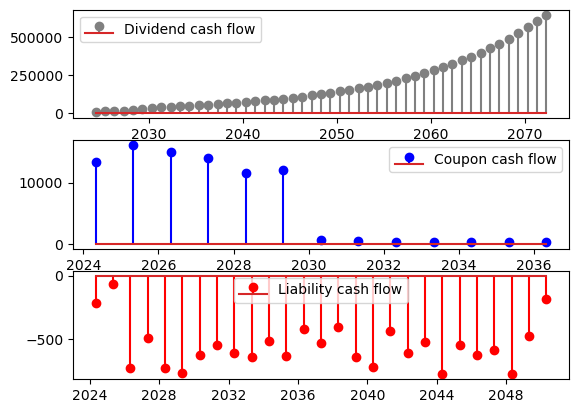

In [153]:
fig, (ax1, ax2, ax3) = plt.subplots(3)

div_mask = div_axis > 0
coup_mask = coup_axis > 0
liab_mask = liab_axis < 0

if div_mask.any():
    ax1.stem(time_axis[div_mask], div_axis[div_mask], linefmt='grey', label='Dividend cash flow')
    ax1.legend()
else:
    ax1.set_title('No dividend cash flows to plot')

if coup_mask.any():
    ax2.stem(time_axis[coup_mask], coup_axis[coup_mask], linefmt='blue', label='Coupon cash flow')
    ax2.legend()
else:
    ax2.set_title('No coupon cash flows to plot')

if liab_mask.any():
    ax3.stem(time_axis[liab_mask], liab_axis[liab_mask], linefmt='red', label='Liability cash flow')
    ax3.legend()
else:
    ax3.set_title('No liability cash flows to plot (e.g. unit-linked mode)')

plt.show()

***

<a id="terminal-cash-flows"></a>

### Terminal cash flows

Each asset in OSEM has a terminal value. For fixed income instruments, these are the notional
payments at the maturity date. For equities, OSEM assumes that all equity positions are sold at
the end of the modelling window at market rates.

In [154]:
not_axis = out["Notional cash flow"]
term_axis = out["Terminal cash flow"]

***

In [155]:
terminal_cf = pd.DataFrame({"Notional cash flow": not_axis,
                            "Terminal cash flow": term_axis})

display(terminal_cf[(terminal_cf.fillna(0) != 0).any(axis=1)])

,Notional cash flow,Terminal cash flow
2026-04-29,137262.614572,0.000000e+00
2027-04-29,171503.740021,0.000000e+00
2029-04-29,232241.407583,0.000000e+00
2031-04-29,39222.783447,0.000000e+00
2036-04-29,37758.752865,0.000000e+00
2073-04-29,0.000000,1.726578e+07


***

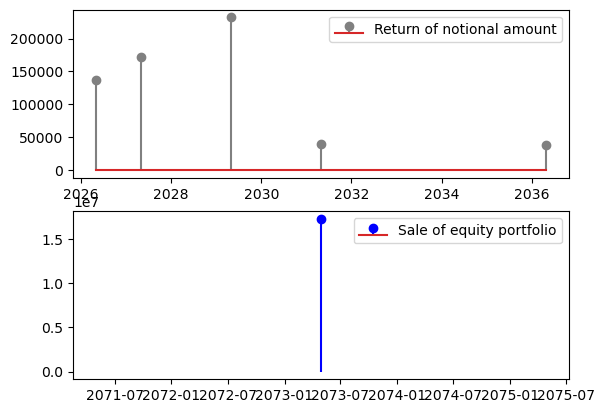

In [156]:
fig, (ax1, ax2) = plt.subplots(2)

not_mask = not_axis > 0
term_mask = term_axis > 0

if not_mask.any():
    ax1.stem(out.index[not_mask], not_axis[not_mask], linefmt='grey', label='Return of notional amount')
    ax1.legend()
else:
    ax1.set_title('No notional cash flows to plot')

if term_mask.any():
    ax2.stem(out.index[term_mask], term_axis[term_mask], linefmt='blue', label='Sale of equity portfolio')
    ax2.legend()
else:
    ax2.set_title('No terminal cash flows to plot')

plt.show()

***

<a id="cash-movement"></a>

### Cash movement

The management of cash between periods is fundamental to OSEM. If the initial cash is high, then
in the first period the large cash position is sold in line with the asset allocation rule. This
is why the initial cash is represented separately. After the first period, cash swings as the
balance of inflows and outflows changes through time.

In [157]:
x_axis = out.index
end_cash_axis = out["End cash"]
start_cash_axis = out["Start cash"]

***

In [158]:
cash_movement = pd.DataFrame({"Start cash": start_cash_axis,
                              "End cash": end_cash_axis,
                              "Cash movement": end_cash_axis - start_cash_axis})

display(cash_movement.head(10))

,Start cash,End cash,Cash movement
2023-04-29,NaN,1.000000e+05,NaN
2024-04-29,1.000000e+05,4.365575e-11,-1.000000e+05
2025-04-29,4.365575e-11,1.382432e-10,9.458745e-11
2026-04-29,1.382432e-10,-5.820766e-11,-1.964509e-10
2027-04-29,-5.820766e-11,-1.455192e-10,-8.731149e-11
2028-04-29,-1.455192e-10,-7.275958e-11,7.275958e-11
2029-04-29,-7.275958e-11,5.820766e-11,1.309672e-10
2030-04-29,5.820766e-11,1.309672e-10,7.275958e-11
2031-04-29,1.309672e-10,1.018634e-10,-2.910383e-11
2032-04-29,1.018634e-10,-1.455192e-10,-2.473826e-10


***

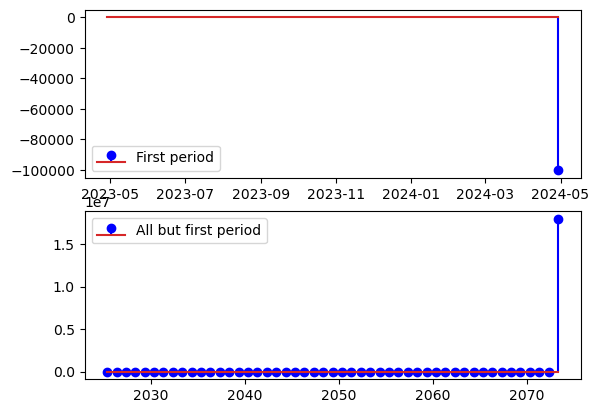

In [159]:
fig, (ax1, ax2) = plt.subplots(2)
ax1.stem(x_axis[0:2], end_cash_axis[0:2]-start_cash_axis[0:2], linefmt='b', label='First period')
ax2.stem(x_axis[2:], end_cash_axis[2:]-start_cash_axis[2:], linefmt='b', label='All but first period')

ax1.legend()
ax2.legend()
plt.show()

***

<a id="end-of-period-market-value"></a>

### End of period market value

The market value is recorded three times per period: at the start, after the portfolio has grown
but before any trading, and at the end once the trading is done.

In [160]:
start_mv_axis = out["After growth market value"]
end_mv_axis = out["End market value"]

***

In [161]:
market_value = pd.DataFrame({"Start market value": out["Start market value"],
                             "After growth market value": start_mv_axis,
                             "End market value": end_mv_axis})

display(market_value.head(10))

,Start market value,After growth market value,End market value
2023-04-29,NaN,NaN,6.052790e+05
2024-04-29,6.052790e+05,6.187107e+05,7.429893e+05
2025-04-29,7.429893e+05,7.585804e+05,7.882543e+05
2026-04-29,7.882543e+05,6.652491e+05,8.312002e+05
2027-04-29,8.312002e+05,6.735715e+05,8.772102e+05
2028-04-29,8.772102e+05,8.961907e+05,9.318511e+05
2029-04-29,9.318511e+05,7.141014e+05,9.840483e+05
2030-04-29,9.840483e+05,1.007106e+06,1.044400e+06
2031-04-29,1.044400e+06,1.029243e+06,1.108012e+06
2032-04-29,1.108012e+06,1.134853e+06,1.178274e+06


***

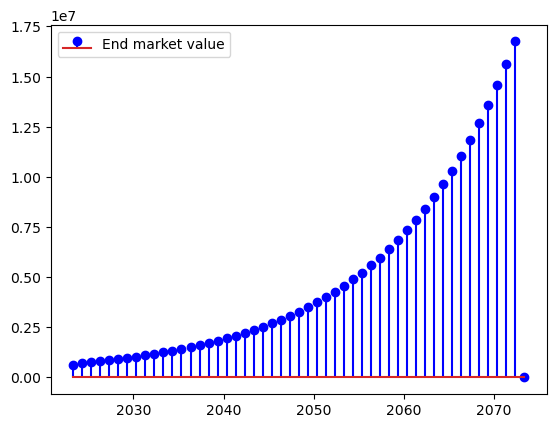

In [162]:
fig, ax = plt.subplots(1)
ax.stem(out.index, end_mv_axis, linefmt='b' , label='End market value')
ax.legend()
plt.show()

***

<a id="section-4"></a>

## 4. Test 1 Return of portfolio

The purpose of this test is to verify if the reported return of the portfolio is equal to the
increase or decrease of the total market value of the portfolio.

Cash paid out by the assets during the period leaves the portfolio before it is repriced: a
maturing bond, for example, drops out of the market value entirely. Those flows have to be added
back, otherwise the recomputed return would report them as a loss. This is the same asset income
that the model itself uses in `portfolio_total_return`.

Terminal value sales are excluded for the same reason as in Test 2: the equities sold at the end
of the modelling window are still inside "After growth market value" when the return is
calculated, so adding their proceeds would count them twice.

The test performs the following check

$$
r_i = (MV^{ag}_i + div_i + coup_i + not_i) / MV^{start}_i - 1
$$

where $r_i$ is the reported "Portfolio return" and the other symbols are as defined in Test 2.

In [163]:
# Asset income has to be added back to the end market value. The flows are removed from the
# asset cash-flow matrices before repricing, so without them a maturing bond looks like a loss
# of its full notional. Terminal sales are excluded: those equities are still in the market
# value at this point, so their proceeds would be counted twice.
asset_income = (out["Dividend cash flow"].fillna(0)
                + out["Coupon cash flow"].fillna(0)
                + out["Notional cash flow"].fillna(0))

return_calculated = ((out["After growth market value"] + asset_income) / out["Start market value"] - 1)[1:]

test_1 = out["Portfolio return"][1:] - return_calculated

# Both sides are returns, so the difference is already dimensionless and a plain absolute
# tolerance is enough. Float64 noise on a ratio of ~1e7 sized values lands around 1e-16.
test_1_tolerance = 1e-10

***

In [164]:
largest_return_diffs = (test_1.abs()
                        .sort_values(ascending=False)
                        .head(5)
                        .rename("Absolute return difference")
                        .to_frame())

display(largest_return_diffs)

,Absolute return difference
2029-04-29,3.122502e-16
2062-04-29,2.775558e-16
2051-04-29,2.220446e-16
2031-04-29,2.081668e-16
2037-04-29,1.249001e-16


***

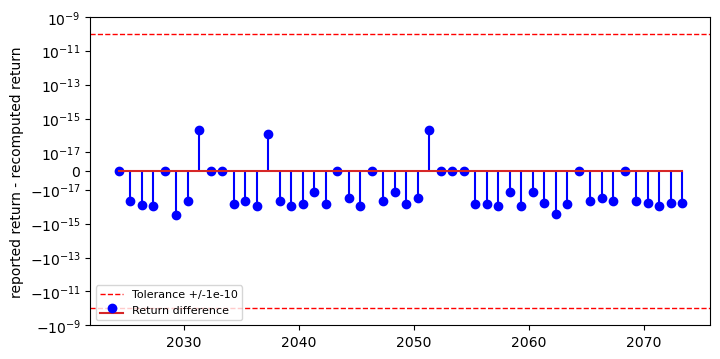

In [165]:
fig, ax = plt.subplots(1, figsize=(8, 4))
ax.stem(out.index[1:], test_1, linefmt='b', label='Return difference')
ax.axhline(test_1_tolerance, color='r', linestyle='--', linewidth=1,
           label=f'Tolerance +/-{test_1_tolerance:.0e}')
ax.axhline(-test_1_tolerance, color='r', linestyle='--', linewidth=1)

# Symmetric log keeps the differences and the tolerance lines, several orders of magnitude
# apart, both legible on one axis
ax.set_yscale('symlog', linthresh=1e-17)
ax.set_ylim(-10 * test_1_tolerance, 10 * test_1_tolerance)
ax.set_ylabel('reported return - recomputed return')
ax.legend(loc='lower left', fontsize=8)
plt.show()

***

<a id="test-1-verdict"></a>

### Verdict

***

In [166]:
# The first period is dropped by the [1:] slice above: it has no "Start market value" to
# measure a return against.
return_diffs = test_1.dropna()
return_breaches = return_diffs[return_diffs.abs() > test_1_tolerance]

print(f"Periods tested         : {len(return_diffs)}")
print(f"Max |return difference|: {return_diffs.abs().max():.3e}  (tolerance {test_1_tolerance:.0e})")
print()

if return_breaches.empty:
    print("TEST 1 PASSED - reported return matches the recomputed return")
else:
    print(f"TEST 1 FAILED - {len(return_breaches)} period(s) out of tolerance:")
    display(pd.DataFrame({"Reported return": out["Portfolio return"][return_breaches.index],
                          "Recomputed return": return_calculated[return_breaches.index],
                          "Difference": return_breaches}))

assert return_breaches.empty, (
    f"Test 1 failed in {len(return_breaches)} period(s): "
    f"{[d.strftime('%Y-%m-%d') for d in return_breaches.index]}"
)

Periods tested         : 50
Max |return difference|: 3.123e-16  (tolerance 1e-10)

TEST 1 PASSED - reported return matches the recomputed return


***

<a id="section-5"></a>

## 5. Test 2 No vanishing cash flows

The purpose of this test is to verify if the inflows and outflows balance at every period. This
test shows that all types of cash flows are accounted for correctly and that there is no
"leakage".

Starting values are

 * Start cash
 * After growth market value

Cash flows occurring during the period and accumulating inside the bank account are

 * Coupon payments
 * Dividend payments
 * Notional payments of fixed income assets

The end values are

 * End cash value
 * End market value

Terminal value sales are deliberately **not** part of this balance. The equity positions sold at
the end of the modelling window are still inside "After growth market value" when it is recorded,
because they are liquidated only after the period return is calculated. The sale therefore
converts market value into cash instead of adding new income, and counting it as an inflow would
double count it. Notional payments are different: matured bonds reprice to zero before "After
growth market value" is taken, so that cash really has left the portfolio.

The test performs the following check

$$
C^{start}_i + MV^{ag}_i + CF^a_i - CF^l_i = C^{end}_i + MV^{end}_i
$$

where

$$
CF^a_i := div_i + coup_i + not_i
$$

and

 * $i$ is the calculation period
 * $C^{start}_i$ is the initial cash position
 * $MV^{ag}_i$ is the market value after portfolio growth but before any trading
 * $CF^l_i$ are the accumulated outflows from company's commitments
 * $C^{end}_i$ is the final cash position
 * $MV^{end}_i$ is the final market value of the portfolio
 * $div_i$ is the accumulated dividend inflows
 * $coup_i$ is the accumulated coupon inflows
 * $not_i$ is the accumulated inflows from matured fixed income instruments (bonds)

Note that the asset growth occurs before trading, therefore "After growth market value" is used
as the starting value.

In [167]:
# The full columns are used here, not the [:-1] slices built for the charts above. Mixing a
# truncated series with a full one makes pandas align on the index and turn the last period
# into NaN, which would silently drop the terminal period from the test.
cf_assets = (out["Coupon cash flow"].fillna(0)
             + out["Dividend cash flow"].fillna(0)
             + out["Notional cash flow"].fillna(0))

liab_full = out["Liability cash flow"].fillna(0)

test_2 = start_cash_axis + start_mv_axis + cf_assets + liab_full - end_mv_axis - end_cash_axis

<a id="relative-residual"></a>

### Relative residual

The absolute residual grows with the portfolio, so a fixed money tolerance would be too tight at
the start of the run and too loose at the end. Dividing by the size of the terms that went into
the balance puts every period on the same footing and turns the residual into a relative error,
directly comparable to the ~1e-16 precision of a 64 bit float.

The terminal period is the noisiest, because it is the only one in which the equity portfolio is
valued twice by two different code paths: "After growth market value" compounds the share price
period by period, while "Terminal cash flow" raises the starting price to a single power over the
whole modelling window. The two agree to a handful of ulps, not bit for bit.

In [168]:
balance_terms = out[["Start cash", "After growth market value", "Coupon cash flow",
                     "Dividend cash flow", "Notional cash flow", "Liability cash flow",
                     "End market value", "End cash"]].fillna(0).abs().sum(axis=1)

# where() guards against a zero denominator, which would otherwise give an infinite residual
test_2_rel = test_2 / balance_terms.where(balance_terms != 0)

# Float64 carries ~1e-16 of relative precision and the balance chains together a few dozen
# operations, so anything up to a few hundred ulps is rounding rather than a leak.
test_2_tolerance = 1e-12

***

In [169]:
largest_residuals = (pd.DataFrame({"Relative residual": test_2_rel,
                                   "Absolute residual": test_2})
                     .dropna()
                     .sort_values("Relative residual", key=lambda s: s.abs(), ascending=False)
                     .head(5))

display(largest_residuals)

,Relative residual,Absolute residual
2073-04-29,-1.451905e-15,-5.215406e-08
2028-04-29,1.014260e-16,1.891749e-10
2061-04-29,8.906506e-17,1.396984e-09
2053-04-29,-8.596050e-17,-7.858034e-10
2044-04-29,7.489815e-17,3.783498e-10


***

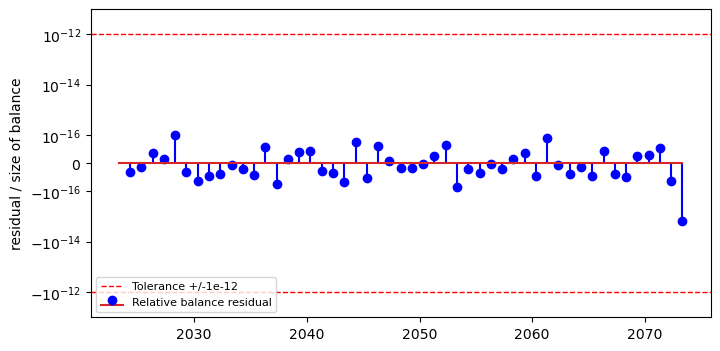

In [170]:
fig, ax = plt.subplots(1, figsize=(8, 4))
ax.stem(x_axis, test_2_rel, linefmt='b', label='Relative balance residual')
ax.axhline(test_2_tolerance, color='r', linestyle='--', linewidth=1, label=f'Tolerance +/-{test_2_tolerance:.0e}')
ax.axhline(-test_2_tolerance, color='r', linestyle='--', linewidth=1)

# Symmetric log keeps the residuals and the tolerance lines, three orders of magnitude apart,
# both legible on one axis
ax.set_yscale('symlog', linthresh=1e-16)
ax.set_ylim(-10 * test_2_tolerance, 10 * test_2_tolerance)
ax.set_ylabel('residual / size of balance')
ax.legend(loc='lower left', fontsize=8)
plt.show()

***

<a id="verdict"></a>

### Verdict

***

In [171]:
# The first row is the opening position rather than a projection period: it has no "Start cash"
# and no "After growth market value", so there is nothing to balance and it is dropped.
residuals = test_2_rel.dropna()
breaches = residuals[residuals.abs() > test_2_tolerance]

print(f"Periods tested          : {len(residuals)}")
print(f"Max |relative residual| : {residuals.abs().max():.3e}  (tolerance {test_2_tolerance:.0e})")
print(f"Max |absolute residual| : {test_2.abs().max():.3e}")
print()

if breaches.empty:
    print("TEST 2 PASSED - no vanishing cash flows")
else:
    print(f"TEST 2 FAILED - {len(breaches)} period(s) out of tolerance:")
    display(pd.DataFrame({"Relative residual": breaches,
                          "Absolute residual": test_2[breaches.index]}))

assert breaches.empty, (
    f"Test 2 failed in {len(breaches)} period(s): "
    f"{[d.strftime('%Y-%m-%d') for d in breaches.index]}"
)

Periods tested          : 50
Max |relative residual| : 1.452e-15  (tolerance 1e-12)
Max |absolute residual| : 5.215e-08

TEST 2 PASSED - no vanishing cash flows


***